# 4. Hyperparameter Optimization

Este notebook ejecuta búsquedas con `GridSearchCV` y `RandomizedSearchCV` sobre los pipelines supervisados del proyecto, comparando el rendimiento **antes y después** del tuning con foco en **Recall** y **F1-Score**.

In [17]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    parent_root = PROJECT_ROOT.parent
    if (parent_root / 'src').exists():
        PROJECT_ROOT = parent_root
    else:
        candidate = PROJECT_ROOT / 'mi_proyecto'
        if (candidate / 'src').exists():
            PROJECT_ROOT = candidate

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_preprocessing import OutlierCapper, SmartImputer, UnknownToNaN
from src.hyperparameter_tuning import get_best_estimators, print_tuning_summary, tune_all_models
from src.model_evaluation import build_stratified_kfold, confusion_matrix_report, roc_curve_points
from src.model_training import get_model_registry

sns.set_theme(style='whitegrid')
metrics_dir = PROJECT_ROOT / 'results' / 'metrics'
plots_dir = PROJECT_ROOT / 'results' / 'plots'
metrics_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

In [18]:
data_path = PROJECT_ROOT / 'data' / 'raw' / 'healthcare-dataset-stroke-data.csv'
df_raw = pd.read_csv(data_path)

target = 'stroke'
X_raw = df_raw.drop(columns=[target, 'id'])
y_raw = df_raw[target]

numeric_features = X_raw.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_features = X_raw.select_dtypes(include=['object', 'string', 'category', 'bool']).columns.tolist()

feature_preprocessor = Pipeline([
    ('unknown_to_nan', UnknownToNaN(columns=categorical_features)),
    ('smart_imputer', SmartImputer()),
    ('outlier_capper', OutlierCapper(columns=numeric_features)),
    ('feature_encoding', ColumnTransformer(
        transformers=[
            ('num', Pipeline([('scaler', StandardScaler())]), numeric_features),
            ('cat', Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features),
        ],
        remainder='drop',
    )),
])

model_registry = get_model_registry(random_state=42)
model_pipelines = {
    name: Pipeline([
        ('preprocessing', feature_preprocessor),
        ('classifier', estimator),
    ])
    for name, estimator in model_registry.items()
}

cv_tuning = build_stratified_kfold(n_splits=3, random_state=42)
baseline_summary = pd.read_csv(metrics_dir / 'baseline_model_comparison.csv')

In [19]:
searches, tuned_summary = tune_all_models(
    model_pipelines=model_pipelines,
    X=X_raw,
    y=y_raw,
    cv=cv_tuning,
    random_state=42,
    n_jobs=1,
    verbose=0,
    n_iter_overrides={'random_forest': 6, 'svc': 5},
)

tuned_summary = tuned_summary.sort_values(
    by=['recall_mean', 'f1_mean', 'roc_auc_mean', 'precision_mean'],
    ascending=[False, False, False, False],
).reset_index(drop=True)

print_tuning_summary(tuned_summary)
tuned_summary.to_csv(metrics_dir / 'tuned_model_comparison.csv', index=False)
tuned_summary.to_json(metrics_dir / 'tuned_model_comparison.json', orient='records', indent=2)

best_params_payload = {name: search.best_params_ for name, search in searches.items()}
(metrics_dir / 'tuned_best_params.json').write_text(json.dumps(best_params_payload, indent=2))
tuned_summary



=== Hyperparameter Tuning Summary ===
              model        search_type refit_metric  best_score  precision_mean  recall_mean  f1_mean  roc_auc_mean
logistic_regression       GridSearchCV       recall    0.831325        0.126262     0.831325 0.219212      0.836373
                svc RandomizedSearchCV           f1    0.223635        0.129729     0.811245 0.223635      0.828987
      random_forest RandomizedSearchCV           f1    0.223101        0.130779     0.763052 0.223101      0.826020


,model,search_type,refit_metric,best_score,best_params,precision_mean,recall_mean,f1_mean,roc_auc_mean
0,logistic_regression,GridSearchCV,recall,0.831325,"{'classifier__C': 0.01, 'classifier__class_wei...",0.126262,0.831325,0.219212,0.836373
1,svc,RandomizedSearchCV,f1,0.223635,"{'classifier__kernel': 'rbf', 'classifier__gam...",0.129729,0.811245,0.223635,0.828987
2,random_forest,RandomizedSearchCV,f1,0.223101,"{'classifier__n_estimators': 200, 'classifier_...",0.130779,0.763052,0.223101,0.826020


In [20]:
comparison_before_after = baseline_summary[['model', 'precision_mean', 'recall_mean', 'f1_mean', 'roc_auc_mean']].merge(
    tuned_summary[['model', 'precision_mean', 'recall_mean', 'f1_mean', 'roc_auc_mean']],
    on='model',
    suffixes=('_baseline', '_tuned'),
)

comparison_before_after.to_csv(metrics_dir / 'before_after_tuning_comparison.csv', index=False)
comparison_before_after.to_json(metrics_dir / 'before_after_tuning_comparison.json', orient='records', indent=2)
comparison_before_after

,model,precision_mean_baseline,recall_mean_baseline,f1_mean_baseline,roc_auc_mean_baseline,precision_mean_tuned,recall_mean_tuned,f1_mean_tuned,roc_auc_mean_tuned
0,logistic_regression,0.130771,0.802939,0.224889,0.834207,0.126262,0.831325,0.219212,0.836373
1,svc,0.121665,0.702367,0.207377,0.798383,0.129729,0.811245,0.223635,0.828987
2,random_forest,0.198333,0.020082,0.036137,0.771874,0.130779,0.763052,0.223101,0.826020


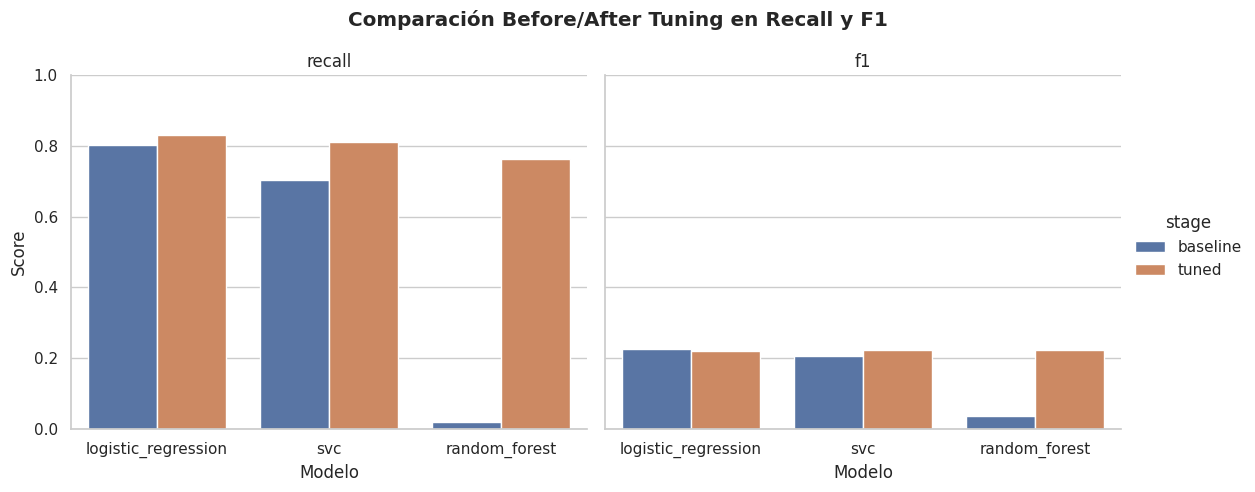

In [21]:
plot_rows = []
for _, row in comparison_before_after.iterrows():
    plot_rows.append({'model': row['model'], 'stage': 'baseline', 'metric': 'recall', 'score': row['recall_mean_baseline']})
    plot_rows.append({'model': row['model'], 'stage': 'tuned', 'metric': 'recall', 'score': row['recall_mean_tuned']})
    plot_rows.append({'model': row['model'], 'stage': 'baseline', 'metric': 'f1', 'score': row['f1_mean_baseline']})
    plot_rows.append({'model': row['model'], 'stage': 'tuned', 'metric': 'f1', 'score': row['f1_mean_tuned']})

comparison_plot_df = pd.DataFrame(plot_rows)
plot = sns.catplot(
    data=comparison_plot_df,
    x='model',
    y='score',
    hue='stage',
    col='metric',
    kind='bar',
    height=5,
    aspect=1.15,
    sharey=True,
)
plot.set_axis_labels('Modelo', 'Score')
plot.set_titles('{col_name}')
plot.set(ylim=(0, 1))
plot.fig.subplots_adjust(top=0.85)
plot.fig.suptitle('Comparación Before/After Tuning en Recall y F1', fontweight='bold')
plot.savefig(plots_dir / 'before_after_tuning_recall_f1.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:
tuned_estimators = get_best_estimators(searches)

X_train, X_test, y_train, y_test = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    stratify=y_raw,
    random_state=42,
)

tuned_holdout_rows = []
tuned_roc_frames = []

for model_name, estimator in tuned_estimators.items():
    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_test)
    y_score = estimator.predict_proba(X_test)[:, 1] if hasattr(estimator, 'predict_proba') else estimator.decision_function(X_test)

    tuned_holdout_rows.append({
        'model': model_name,
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_score),
    })

    roc_df = roc_curve_points(y_test, y_score)
    roc_df['model'] = model_name
    tuned_roc_frames.append(roc_df)

tuned_holdout_metrics = pd.DataFrame(tuned_holdout_rows).sort_values(
    by=['recall', 'f1', 'roc_auc', 'precision'],
    ascending=[False, False, False, False],
).reset_index(drop=True)
tuned_holdout_metrics.to_csv(metrics_dir / 'tuned_holdout_metrics.csv', index=False)
tuned_holdout_metrics.to_json(metrics_dir / 'tuned_holdout_metrics.json', orient='records', indent=2)
tuned_holdout_metrics

/home/tomy/Downloads/cdd_ev2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,model,precision,recall,f1,roc_auc
0,logistic_regression,0.133987,0.82,0.230337,0.841543
1,svc,0.123418,0.78,0.213115,0.825329
2,random_forest,0.120370,0.78,0.208556,0.819074


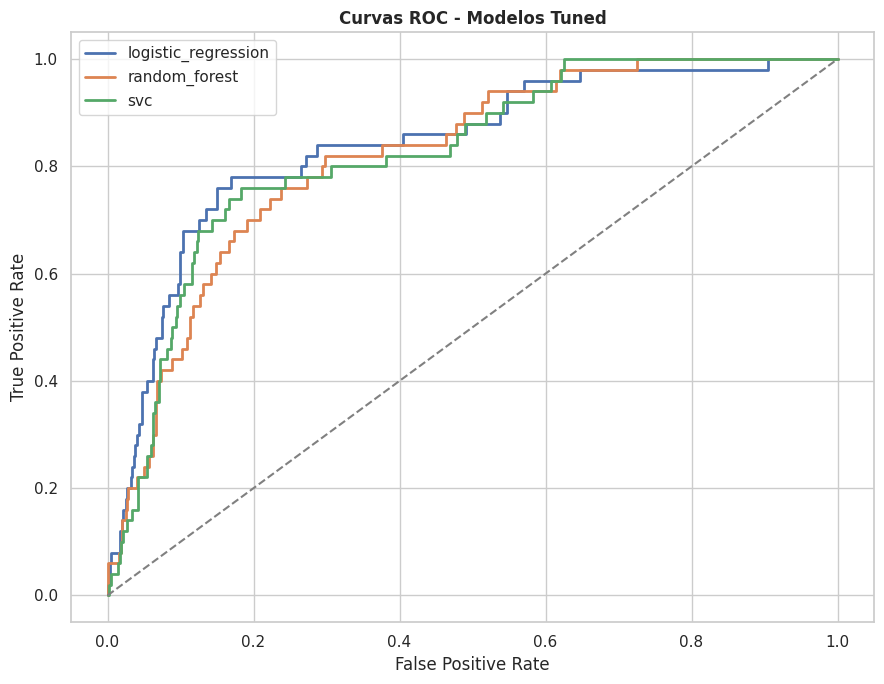

In [23]:
tuned_roc_plot_df = pd.concat(tuned_roc_frames, ignore_index=True)

plt.figure(figsize=(9, 7))
for model_name in tuned_roc_plot_df['model'].unique():
    subset = tuned_roc_plot_df[tuned_roc_plot_df['model'] == model_name]
    plt.plot(subset['fpr'], subset['tpr'], linewidth=2, label=model_name)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Curvas ROC - Modelos Tuned', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig(plots_dir / 'tuned_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

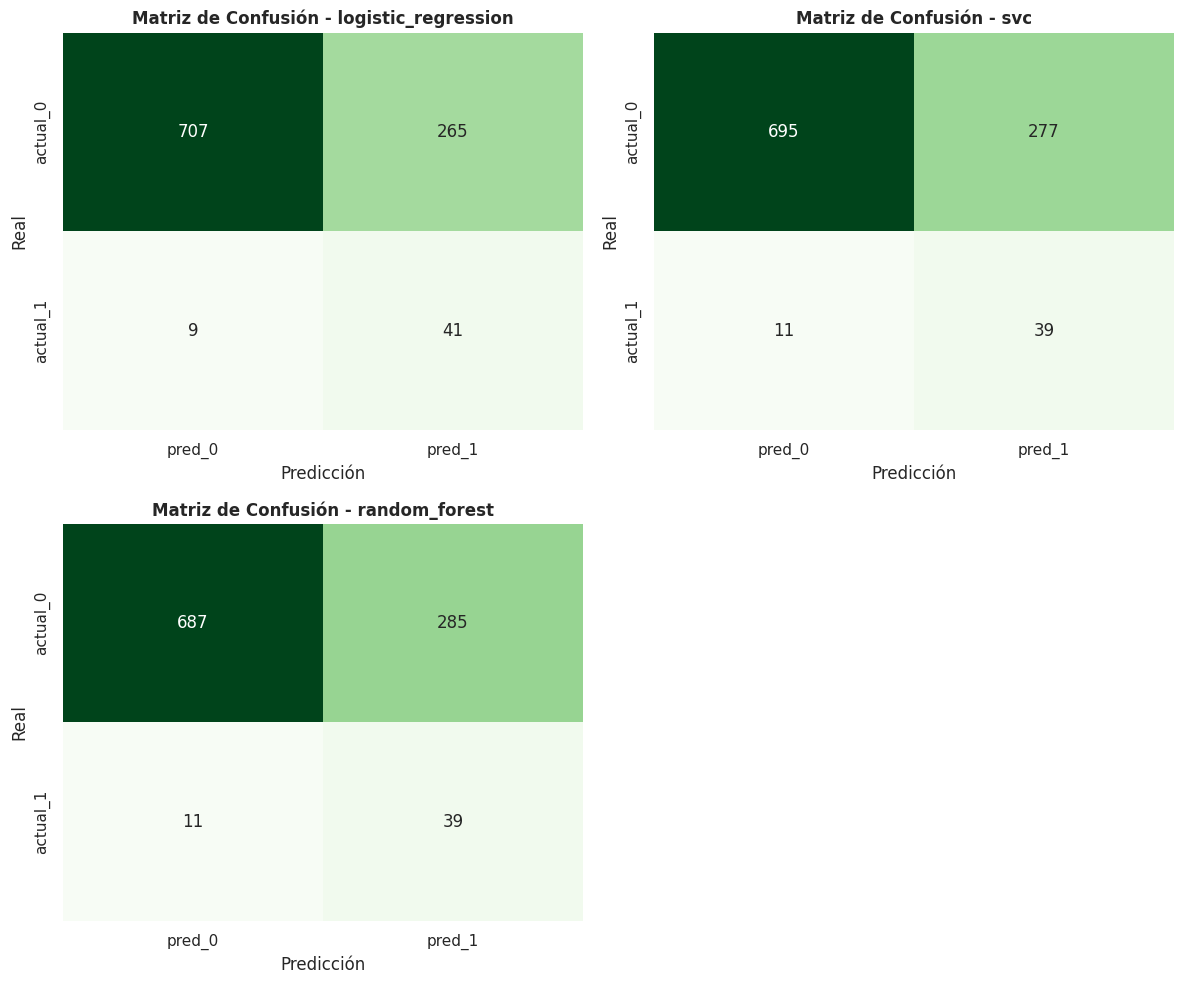

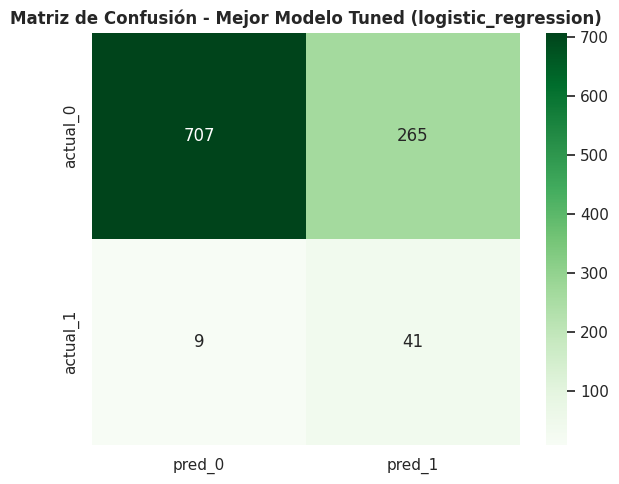

Mejor modelo tras tuning: logistic_regression


,model,precision,recall,f1,roc_auc
0,logistic_regression,0.133987,0.82,0.230337,0.841543
1,svc,0.123418,0.78,0.213115,0.825329
2,random_forest,0.120370,0.78,0.208556,0.819074


In [24]:
best_tuned_model_name = tuned_holdout_metrics.iloc[0]['model']

tuned_confusion_rows = []
ordered_models = tuned_holdout_metrics['model'].tolist()
n_models = len(ordered_models)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, model_name in zip(axes, ordered_models):
    estimator = tuned_estimators[model_name]
    y_pred = estimator.predict(X_test)
    cm_df = confusion_matrix_report(y_test, y_pred)

    for actual_label, row in cm_df.iterrows():
        for predicted_label, value in row.items():
            tuned_confusion_rows.append({
                'model': model_name,
                'actual': actual_label,
                'predicted': predicted_label,
                'count': int(value),
            })

    sns.heatmap(cm_df, annot=True, fmt='g', cmap='Greens', ax=ax, cbar=False)
    ax.set_title(f'Matriz de Confusión - {model_name}', fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

for ax in axes[n_models:]:
    ax.axis('off')

tuned_confusion_long_df = pd.DataFrame(tuned_confusion_rows)
tuned_confusion_long_df.to_csv(metrics_dir / 'tuned_confusion_matrices.csv', index=False)

plt.tight_layout()
plt.savefig(plots_dir / 'tuned_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

best_tuned_model = tuned_estimators[best_tuned_model_name]
y_best_tuned_pred = best_tuned_model.predict(X_test)
tuned_cm_df = confusion_matrix_report(y_test, y_best_tuned_pred)
tuned_cm_df.to_csv(metrics_dir / 'tuned_best_confusion_matrix.csv')

plt.figure(figsize=(6, 5))
sns.heatmap(tuned_cm_df, annot=True, fmt='g', cmap='Greens')
plt.title(f'Matriz de Confusión - Mejor Modelo Tuned ({best_tuned_model_name})', fontweight='bold')
plt.tight_layout()
plt.savefig(plots_dir / 'tuned_best_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mejor modelo tras tuning: {best_tuned_model_name}')
tuned_holdout_metrics.head(3)
